## Breast Cancer Detection

## Import Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import( 
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
    )

## Load Dataset

In [7]:
data = load_breast_cancer() 
X = pd.DataFrame(data.data, columns = data.feature_names)
Y = pd.Series(data.target) 

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


## Dataset Understanding

In [8]:

print("Shape of Dataset:", X.shape)

print("\nFirst 5 Rows:")
X.head()

Shape of Dataset: (569, 30)

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Class Distribution Check

In [9]:
# Check Class Distribution

class_distribution = y.value_counts()

print(class_distribution)

1    357
0    212
Name: count, dtype: int64


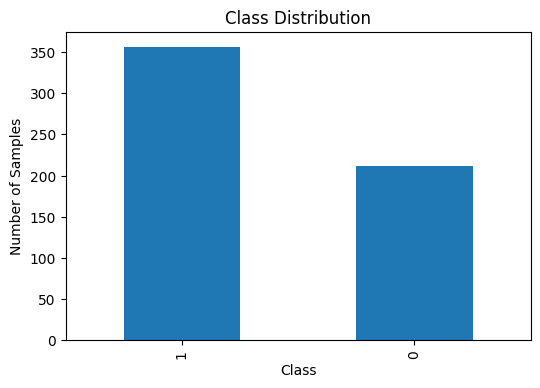

In [10]:
# Visualize Class Distribution

plt.figure(figsize=(6,4))

class_distribution.plot(kind='bar')

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

In [11]:
# Class Mapping

print({
    0: data.target_names[0],
    1: data.target_names[1]
})

{0: np.str_('malignant'), 1: np.str_('benign')}


## Train-Test Split

In [12]:
# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


## Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


## Model Building & Training

In [14]:
# Create Logistic Regression Model

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


## Prediction

In [15]:
# Make Predictions

y_pred = log_model.predict(X_test_scaled)

print("Predictions Generated Successfully")

Predictions Generated Successfully


## Basic Accuracy Check

In [16]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


## Confusion Matrix

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


## Confusion Matrix Visualization

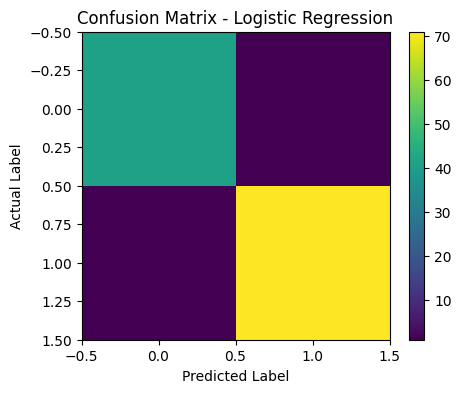

In [18]:
plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.show()

## Precision, Recall, F1 Score

In [23]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112


## Complete Classification Report

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## ROC Curve & AUC

In [25]:
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:5])

[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10]


## Calculate AUC Score

In [26]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.9953703703703703


## Plot ROC Curve

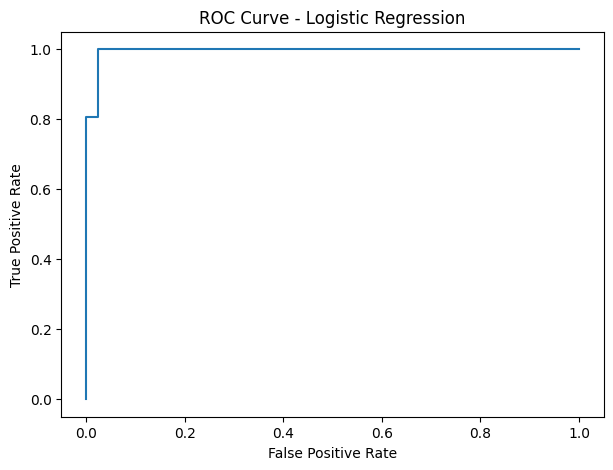

In [27]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.show()

## Handling Imbalanced Data

In [28]:
# Logistic Regression with Class Weight Balanced

balanced_log_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

balanced_log_model.fit(X_train_scaled, y_train)

print("Balanced Logistic Regression Trained Successfully")

Balanced Logistic Regression Trained Successfully


## Prediction:

In [29]:
# Predictions from Balanced Model

balanced_pred = balanced_log_model.predict(X_test_scaled)

## Evaluation:

In [30]:
# Balanced Model Performance

balanced_accuracy = accuracy_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

print("Balanced Logistic Regression Accuracy:", balanced_accuracy)
print("Balanced Logistic Regression F1 Score:", balanced_f1)

Balanced Logistic Regression Accuracy: 0.956140350877193
Balanced Logistic Regression F1 Score: 0.9645390070921985


## Decision Tree Model

In [31]:
# Create Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train Model

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [32]:
# Make Predictions using Decision Tree

dt_pred = dt_model.predict(X_test)

In [33]:
# Decision Tree Evaluation

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1 Score:", dt_f1)

Decision Tree Accuracy: 0.9122807017543859
Decision Tree Precision: 0.9558823529411765
Decision Tree Recall: 0.9027777777777778
Decision Tree F1 Score: 0.9285714285714286


## Model Comparison

In [34]:
# Model Comparison Table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy,
        dt_accuracy
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, balanced_pred),
        dt_precision
    ],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, balanced_pred),
        dt_recall
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred),
        balanced_f1,
        dt_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Balanced Logistic Regression,0.956140,0.985507,0.944444,0.964539
2,Decision Tree,0.912281,0.955882,0.902778,0.928571


## Best Model Identify

In [35]:
# Best Model based on F1 Score

best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Performing Model:")
best_model

Best Performing Model:


Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object

## Conclusion 

In this task, a binary classification model was developed using the Breast Cancer dataset.

Logistic Regression was implemented as the baseline model and evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and AUC score.

To handle class imbalance, class_weight='balanced' was applied. A Decision Tree Classifier was also trained and compared with Logistic Regression models.

The best performing model was selected based on evaluation metrics, especially F1-score, to ensure reliable classification performance.